In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
pd.set_option('display.max_columns', None)

In [86]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [87]:
df.shape

(3544, 18)

In [88]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pareena mi casa,sector 68,1.90,9228.0,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49
1,flat,alpha corp gurgaonone,sector 84,2.28,8769.0,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61
2,flat,m3m sierra 68,sector 68,1.10,8987.0,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127
3,house,ireo victory valley4.0 ?,sector 67,8.00,22222.0,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151
4,flat,kiran residency,sector 56,1.54,8324.0,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98


In [89]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [90]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98


#### **luxury score**

<Axes: xlabel='luxury_score'>

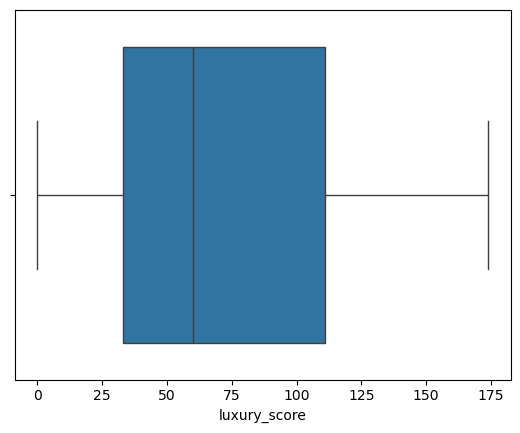

In [91]:
sns.boxplot(x=df['luxury_score'])

In [92]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [93]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [94]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49,Low
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61,Medium
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127,Medium
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151,High
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98,Medium


#### **floorNum**

<Axes: xlabel='floorNum'>

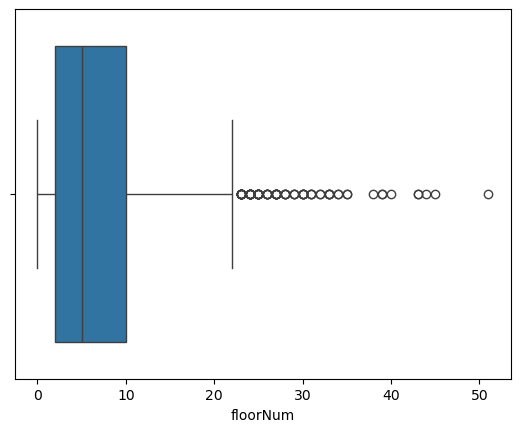

In [95]:
sns.boxplot(x=df['floorNum'])

In [96]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [97]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [98]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 68,1.90,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49,Low,Low Floor
1,flat,sector 84,2.28,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61,Medium,Mid Floor
2,flat,sector 68,1.10,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127,Medium,Low Floor
3,house,sector 67,8.00,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151,High,Mid Floor
4,flat,sector 56,1.54,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98,Medium,Mid Floor


In [99]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [100]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 68,1.90,3,3,3+,Under Construction,2288.0,0,1,0,0,0,0,Low,Low Floor
1,flat,sector 84,2.28,4,4,3+,Relatively New,2998.0,0,1,0,0,0,0,Medium,Mid Floor
2,flat,sector 68,1.10,2,2,3,Relatively New,1150.0,0,0,0,0,0,1,Medium,Low Floor
3,house,sector 67,8.00,6,7,3+,Moderately Old,3600.0,1,1,1,1,0,1,High,Mid Floor
4,flat,sector 56,1.54,3,4,3+,Old Property,1900.0,0,1,0,0,0,0,Medium,Mid Floor


In [101]:
train_df.drop(columns=['pooja room', 'study room', 'others'],inplace=True)


In [103]:
train_df.to_csv('gurgaon_properties_post_feature_selection_v2.csv', index=False)

In [105]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 68,1.90,3,3,3+,Under Construction,2288.0,1,0,0,Low,Low Floor
1,flat,sector 84,2.28,4,4,3+,Relatively New,2998.0,1,0,0,Medium,Mid Floor
2,flat,sector 68,1.10,2,2,3,Relatively New,1150.0,0,0,1,Medium,Low Floor
3,house,sector 67,8.00,6,7,3+,Moderately Old,3600.0,1,1,1,High,Mid Floor
4,flat,sector 56,1.54,3,4,3+,Old Property,1900.0,1,0,0,Medium,Mid Floor
